<a href="https://colab.research.google.com/github/Mars-Martiny/CITS1003/blob/2022s1/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center>CITS5508 Assignment 2:</center>

**File name: Assignment2.ipynb**<br>
**Name:** Maryam Saeed<br>
**Student ID:** 23121354<br>
**Date:** 2025<br>

This report investigates two topics: Voting Classifier, and Random Forest classifier.
The first part investigates a Voting Classifier (VC) classification model trained on a dataset from the *Diagnostic Wisconsin Breast Cancer Database* [1].
The second part investigates a Random Forest (RF) classification model trained on the *Labeled Faces in the Wild* dataset [1].  
 on the

Part 1: [Voting Classifier](#vc)
 - [Dataset](#dataset)
 - [Split Data](#split_data)
 - [Fit Base Models](#fit_base_models)
 - [Voting Classifier](#voting_classifier)
 - [Evaluation and Results](#evaluation_results)
 - [Discussion](#discussion)

Part 2: [Random Forest](#random_forest)
 - [Labeled Faces in the Wild Dataset](#load_LFW)
 - [Split Data](#split_data)
 - [Classes](#classes)
 - [Random Forest Classifier](#rf_classifier)
 - [Principal Component Analysis](#pca)
 - [Training on PCA Transformed Data](#train_pca)
 - [Comparison](#comparison)


### Import the Libraries


In [ ]:
# Libraries
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-Learn imports
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC


# For plot to display in Jupyter notebook
%matplotlib inline

# Import plotting modules
import seaborn as sns
from pandas.plotting import scatter_matrix  # produces grid of scatter plots

# Set font size for the parameters (ensures consistency)
plt.rcParams['font.size'] = '12'

# Voting Classifier
<a id=vc></a>


In this section we build a Voting Classifier using the dataset from the *Diagnostic Wisconsin Breast Cancer Database* [1].

## 1.1 Dataset
<a id=dataset></a>


According to the information contained in the `wdbc.names`:

- Column 1 and 2 are ID number and Diagnosis respectively.
- Columns 3 - 32 are the mean, standard error, and "worst" (or largest) of ten real-valued features (3 groups of 10).

(The dataset is loaded in assuming that the `wdbc.data` file is within the current directory)


In [ ]:
# define column names as outlined in wdbc.names
column_names = ["ID_Number", "Diagnosis",
                "Radius_Mean", "Texture_Mean", "Perimeter_Mean", "Area_Mean", "Smoothness_Mean", "Compactness_Mean", "Concavity_Mean", "ConcavePoints_Mean", "Symmetry_Mean", "FractalDimension_Mean",
                "Radius_SE", "Texture_SE", "Perimeter_SE", "Area_SE", "Smoothness_SE", "Compactness_SE", "Concavity_SE", "ConcavePoints_SE", "Symmetry_SE", "FractalDimension_SE",
                "Radius_Wost", "Texture_Wost", "Perimeter_Wost", "Area_Wost", "Smoothness_Wost", "Compactness_Wost", "Concavity_Wost", "ConcavePoints_Wost", "Symmetry_Wost", "FractalDimension_Wost" ]

# Load in dataset with the column names listed
try:
    df = pd.read_csv("wdbc.data", header=None, names = column_names)
    print("Dataset loaded successfully \n")
# Catch potential errors
except FileNotFoundError:
    print("Error: File not found. Make sure 'wdbc.data' is in the current directory.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

# Display the first few rows to check if data was read in successfully
print(df.head())

Dataset loaded successfully 

   ID_Number Diagnosis  Radius_Mean  Texture_Mean  Perimeter_Mean  Area_Mean  \
0     842302         M        17.99         10.38          122.80     1001.0   
1     842517         M        20.57         17.77          132.90     1326.0   
2   84300903         M        19.69         21.25          130.00     1203.0   
3   84348301         M        11.42         20.38           77.58      386.1   
4   84358402         M        20.29         14.34          135.10     1297.0   

   Smoothness_Mean  Compactness_Mean  Concavity_Mean  ConcavePoints_Mean  ...  \
0          0.11840           0.27760          0.3001             0.14710  ...   
1          0.08474           0.07864          0.0869             0.07017  ...   
2          0.10960           0.15990          0.1974             0.12790  ...   
3          0.14250           0.28390          0.2414             0.10520  ...   
4          0.10030           0.13280          0.1980             0.10430  ...   

  

The dataset contains 569 non-null entries, with 32 attributes recorded for each entry. The data type of the first two attributes, `ID_Number` and `Diagnosis`, are `int64` type and `object` type respectively. All other attributes are of `float64` type, the real-valued features.

Diagnosis is categorical with two possible values (M = malignant, B = benign). Of the 569 entries, 357 are categorised as "B" (benign) and only 212 are categorised as "M" (malignant). Within the dataset there is a class imbalance, this may have an impact on the Support Vector Machine classification model trained on this dataset.
The these observations align with the description of the dataset given in `wdbc.names`.


The `ID_Number` column is not needed for our goals, we will drop the column.

We will also replace the categorical values in the `Diagnosis` column with numerical labels, the binary classification can simply be mapped to {0,1}. Assigning 0 to the benign class as it is the original or 'normal' state, and 1 to the malignant class as it represents the presence of disease or abnormality (i.e. `'B'` $\to 0$ and `'M'` $\to 1$). Within many machine learning conventions, the positive class (typically 1) represents the condition of interest. This mapping therefore reflects the clinical context of the data, where we are primarily concerned with detecting malignancy.


In [ ]:
# Information contained within the dataset
print(df.info())

# Class distribution for Diagnosis (only categorical data type)
print('\n', df["Diagnosis"].value_counts())


# Drop unnecessary columns
df_new = df.drop(columns=['ID_Number'])

# Map categorical values to numerical values: {B,M} -> {0,1}
df_new['Diagnosis'] = df_new['Diagnosis'].map({'B': 0, 'M': 1})


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Number              569 non-null    int64  
 1   Diagnosis              569 non-null    object 
 2   Radius_Mean            569 non-null    float64
 3   Texture_Mean           569 non-null    float64
 4   Perimeter_Mean         569 non-null    float64
 5   Area_Mean              569 non-null    float64
 6   Smoothness_Mean        569 non-null    float64
 7   Compactness_Mean       569 non-null    float64
 8   Concavity_Mean         569 non-null    float64
 9   ConcavePoints_Mean     569 non-null    float64
 10  Symmetry_Mean          569 non-null    float64
 11  FractalDimension_Mean  569 non-null    float64
 12  Radius_SE              569 non-null    float64
 13  Texture_SE             569 non-null    float64
 14  Perimeter_SE           569 non-null    float64
 15  Area_S

Ensure columns have been dropped correctly and sucessful mapping of `Diagnosis` column data.

The scale of values recorded for some features are very different, requires feature scaling.

In [ ]:
# Description of values contained in each column
print(df_new.describe())

        Diagnosis  Radius_Mean  Texture_Mean  Perimeter_Mean    Area_Mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       Smoothness_Mean  Compactness_Mean  Concavity_Mean  ConcavePoints_Mean  \
count       569.000000        569.000000      569.000000          569.000000   
mean          0.096360          0.104341        0.088799            0.048919   
std           0.014064          0.052813        0.079720          

## 1.2 Split Data
<a id=split_data></a>


The `ID_Number` column is not needed for our goals, we will drop the column. We will also replace the categorical values in the `Diagnosis` column with numerical labels, the binary classification can simply be mapped to {0,1}. Assigning 0 to the benign class as it is the original or 'normal' state, and 1 to the malignant class as it represents the presence of disease or abnormality (i.e. `'B'` $\to 0$ and `'M'` $\to 1$). Within many machine learning conventions, the positive class (typically 1) represents the condition of interest. This mapping therefore reflects the clinical context of the data, where we are primarily concerned with detecting malignancy.

The dataset is split into training and testing subsets, with 80% of the data used for training the models and 20% used for testing those trained models. The split is also stratified.

Stratification is required as the data does not equally represent the two Diagnosis classes, Benign (0) and Malignant (1). This was noted in section [1.1 Dataset](#dataset). The class distribution observed was 62.7% Benign and 37.3% Malignant.

Stratification ensures we obtain training and test sets which preserve the class distribution as seen in the whole dataset. Avoids the risk of getting an unbalanced training set, poor generalisation in the model, and unreliable evaluation metrics.

The class distribution for both the training and testing sets closely match the original distribution within the dataset.

In [ ]:
# Standardize the features
X = df_new.drop(columns='Diagnosis')  # 30 features
y = df_new['Diagnosis']               # 0 = benign, 1 = malignant

In [ ]:
# Split data into training and testing with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check stratification maintained class distribution
print("\nTrain set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


Train set class distribution:
Diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test set class distribution:
Diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## 1.3 Fit Base Models
<a id=fit_base_models></a>

Using scikit-learn, three base models are fitted to the training data:
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

Similar to how the data splitting required stratification to preserve the class proportions, the cross validation within the grid search also requires stratification. The justification for doing so is the same. We will use grid search with a 5-fold cross validation to find the optimal hyperparameters for each model.

The use of bagging when training was considered, however, all models demonstrated stable and generalizable performance with hyperparameter tuning alone. The decision to omit bagging was based on empirical performance, maintaining simplicity, and ensuring computational efficiency. The process of grid selection inherently regulates model complexity and generalization, diminishing the need for variance-mitigation strategies such as bagging.

Scoring the perfomance based solely on accuracy would be inappropriate as it is not a reliable metric. Depending on the application, a higher precision or higher recall would be preferrable. In this scenario, false negatives are costly, so recall is more important than precision.

In [ ]:
# Helper funciton to train each model type using grid search with 5-fold stratified data
def helper_train_model(X_train_data, y_train_data, search_pipeline, param_grid):  # Requires model-specific pipeline and parameters
    # Grid search with 5-fold Cross-Validation (stratified)
    grid_search = GridSearchCV(
        estimator=search_pipeline,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='recall',  # Score performance based on recall
        refit=True,
        n_jobs=-1
    )

    # Train all combinations on training folds, validate on val fold
    grid_search.fit(X_train_data, y_train_data)

    # Print optimal hyperparameters
    print(f"Optimal hyperparameter values: {grid_search.best_params_}\n")

    # Create table of validation Recall scores for each fold
    cv_df = pd.DataFrame({
        'Fold': range(1, 6),
        '  Score': [
            f"{grid_search.cv_results_[f'split{i}_test_score'][grid_search.best_index_]:.3f}"
            for i in range(5)
        ]
    })
    print("Validation Recall scores:\n" + cv_df.to_string(index=False) + '\n')

    # Print mean validation score
    best_score = grid_search.best_score_
    print(f"Mean Validation Recall-Weighted Score: {best_score:.3f}")

    # Return the best estimator, already trained on full training data
    return grid_search.best_estimator_

### Logistic Regression


The hyperparameters chosen were $C$ with 4 different values and `solver` with 2 different values (using k-fold cross-validation with k=5). In total 40 model were fit to find the model with the optimal hyperparameters.

Optimal hyperparameter values: $C=100$, `solver`$=$ `lbfgs`

In [ ]:
# Logistic regression pipeline // MinMaxScaler() used since gradient descent is sensitive to scale
lr_pipeline = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
)
# Parameter grid with LR hyperameter values
lr_param_grid = {
    'logisticregression__C': [0.1, 1, 10, 100],      # Regularisation strength
    'logisticregression__solver': ['lbfgs', 'saga']  # Optimisation algorithm
}

# Use helper function to find best logistic regression model
best_lr_model = helper_train_model(X_train, y_train, lr_pipeline, lr_param_grid)

Optimal hyperparameter values: {'logisticregression__C': 100, 'logisticregression__solver': 'lbfgs'}

Validation Recall scores:
 Fold   Score
    1   0.882
    2   0.971
    3   1.000
    4   0.912
    5   0.971

Mean Validation Recall-Weighted Score: 0.947


### Random Forest


The hyperparameters chosen were $n$-estimators with 4 different values and max-depth also with 4 different values (using k-fold cross-validation with k=5). In total 80 model were fit to find the model with the optimal hyperparameters.

Optimal hyperparameter values: $n$-estimators$=100$, max-depth $=5$

In [ ]:
# Random forest pipeline  // MinMaxScalar() was used for consistency and to reduce computation time
rf_pipeline = make_pipeline(
    MinMaxScaler(),
    RandomForestClassifier(random_state=42)
)

# Parameter grid with RF hyperameter values
rf_param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 150, 200],  # Number of trees in forest
    'randomforestclassifier__max_depth': [None, 5, 10, 20]        # Maximum depth of decision tree
}

# Use helper function to find best random forest model
best_rf_model = helper_train_model(X_train, y_train, rf_pipeline, rf_param_grid)

Optimal hyperparameter values: {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 100}

Validation Recall scores:
 Fold   Score
    1   0.941
    2   1.000
    3   0.882
    4   0.941
    5   0.971

Mean Validation Recall-Weighted Score: 0.947


### Support Vector Machine

The hyperparameters chosen were $C$ with 4 different values, $\gamma$ also with 4 different values, and `kernel` with 2 different values (using k-fold cross-validation with k=5). In total 160 model were fit to find the model with the optimal hyperparameters.

Optimal hyperparameter values: $C=10$, $\gamma=1$, `kernel`$=$ `rbf`

In [ ]:
# Support vector machine pipeline // MinMaxScalar used as we try linear and rbf kernels
svm_pipeline = make_pipeline(
    MinMaxScaler(),
    SVC(probability=True, decision_function_shape='ovr', random_state=42)
)

# Parameter grid with support vector machine hyperameter values
svm_param_grid = {
    'svc__C': [0.1, 1, 10, 100],      # Regularisation strength
    'svc__gamma': [0.01, 0.1, 1, 5],  # Kernel coefficient for RBF
    'svc__kernel': ['linear', 'rbf']  # Kernels
}

# Use helper function to find best support vector machine model
best_svm_model = helper_train_model(X_train, y_train, svm_pipeline, svm_param_grid)

Optimal hyperparameter values: {'svc__C': 10, 'svc__gamma': 1, 'svc__kernel': 'rbf'}

Validation Recall scores:
 Fold   Score
    1   0.912
    2   1.000
    3   0.971
    4   0.971
    5   0.971

Mean Validation Recall-Weighted Score: 0.965


## 1.4 Voting Classifier
<a id=voting_classifier></a>


A Voting Classifier is built with the three base models found above. Within the pipeline created for the Voting Clasifier we have set `voting='soft'` which implements soft-voting, meaning the predicted class is the class that receives the highest average class probability.

The hyperparameter chosen was `weights`  with 7 different values (using k-fold cross-validation with k=5). In total 35 model were fit to find the model with the optimal hyperparameters.

Optimal hyperparameter values:  `weights` $=[1,1,1]$

In [ ]:
# Create VotingClassifier with soft voting
voting_clf_pipeline = VotingClassifier(
    estimators=[
        ('lr', best_lr_model),
        ('rf', best_rf_model),
        ('svm', best_svm_model)
    ],
    voting='soft',    # Use probabilities
    n_jobs=1
)

# Parameter grid with hyperameter values
voting_clf_param_grid = {
    'weights': [      # Weights of base classifiers [lr, rf, svm]
        [1, 1, 1],    # Equal weighting
        [2, 1, 1],    # More influence -> lr
        [1, 2, 1],    #                -> rf
        [1, 1, 2],    #                -> svc
        [2, 2, 1],    #                -> lr & rf
        [2, 1, 2],    #                -> lr & svc
        [1, 2, 2]     #                -> rf & svc
    ]
}

# Use helper function to find best soft VC model
best_voting_clf_model = helper_train_model(X_train, y_train, voting_clf_pipeline, voting_clf_param_grid)

Optimal hyperparameter values: {'weights': [1, 1, 1]}

Validation Recall scores:
 Fold   Score
    1   0.912
    2   1.000
    3   0.971
    4   0.971
    5   0.971

Mean Validation Recall-Weighted Score: 0.965


## 1.5 Evaluation and Results
<a id=evaluation_results></a>


All four models are evaluated on the testing set, allowing us to see if our model generalises well on data it was not trained on. The *precision*, *recall* and *f1-score* of each model are displayed as they are the metrics with which we are most concerned with for our data.
The confusion matrix plots provide a visualisation of the accuracy in the predictions of the models and display exactly how many of the test examples fall within each category.

We can see that only the Logistic Regression model produced 1 false positive, all other models performed well in terms of classifying Malignant only when it is truly malignant as they had no false positives. However, all 3 base models produced 3 false negatives which, in this context, has a greater significance as it is classifying Benign when in reality the cell is malignant. The Voting Classifier, on the other hand, only produced 2 false negatives.

In [ ]:
# Create a table of precision, recall, and F1-scores for each model and plot a confusion matrix for each model
def model_evaluation_test(model_name, model, X_test, y_test):
  # Use final model to predict on the test set
  y_test_pred = model.predict(X_test)

  # Test accuracy
  test_accuracy = accuracy_score(y_test, y_test_pred)
  print(f"\n{model_name}:")
  print(f"Test Accuracy: {test_accuracy:.3f}\n")

  # Detailed Classification Report
  print("Classification Report (Test Set):")
  print(classification_report(y_test, y_test_pred, target_names=['Benign', 'Malignant'], digits=3))

  # Plot the Confusion Matrix
  ConfusionMatrixDisplay.from_estimator(
      model,
      X_test,
      y_test,
      display_labels=['Benign', 'Malignant'],
  )
  plt.title(f"{model_name} - Confusion Matrix")
  plt.show()


Logistic Regression:
Test Accuracy: 0.965

Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign      0.959     0.986     0.973        72
   Malignant      0.975     0.929     0.951        42

    accuracy                          0.965       114
   macro avg      0.967     0.957     0.962       114
weighted avg      0.965     0.965     0.965       114



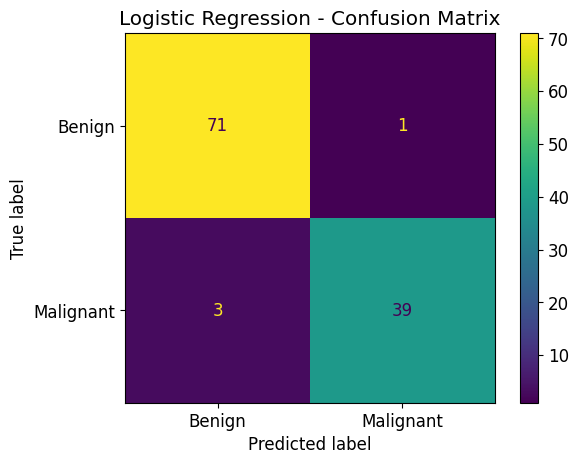

In [ ]:
# Evaluate all models found on test set using the model_evaluation_test funciton
model_evaluation_test('Logistic Regression', best_lr_model, X_test, y_test)


Random Forest:
Test Accuracy: 0.974

Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign      0.960     1.000     0.980        72
   Malignant      1.000     0.929     0.963        42

    accuracy                          0.974       114
   macro avg      0.980     0.964     0.971       114
weighted avg      0.975     0.974     0.973       114



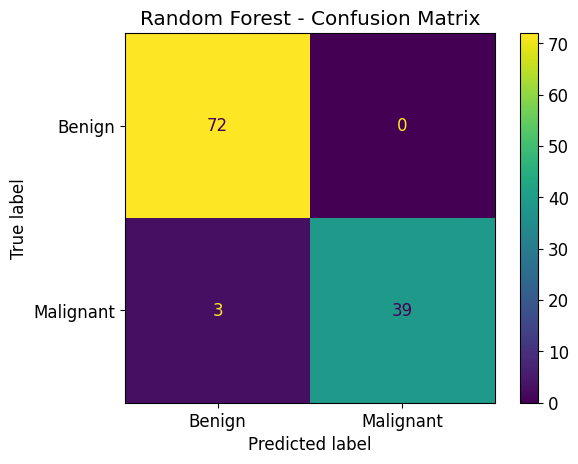

In [ ]:
# Evaluate Random Forest model on test set
model_evaluation_test('Random Forest', best_rf_model, X_test, y_test)


Support Vector Machine:
Test Accuracy: 0.974

Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign      0.960     1.000     0.980        72
   Malignant      1.000     0.929     0.963        42

    accuracy                          0.974       114
   macro avg      0.980     0.964     0.971       114
weighted avg      0.975     0.974     0.973       114



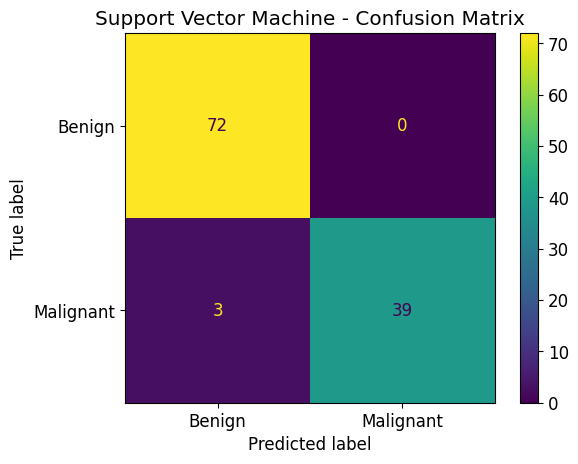

In [ ]:
# Evaluate Support Vector Machine model on test set
model_evaluation_test('Support Vector Machine', best_svm_model, X_test, y_test)


Voting Classifier (soft):
Test Accuracy: 0.982

Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign      0.973     1.000     0.986        72
   Malignant      1.000     0.952     0.976        42

    accuracy                          0.982       114
   macro avg      0.986     0.976     0.981       114
weighted avg      0.983     0.982     0.982       114



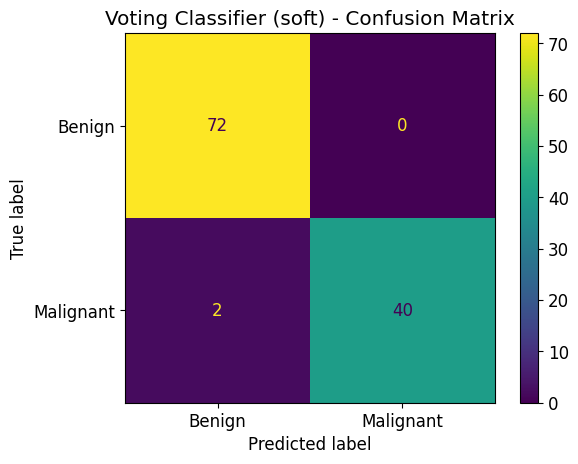

In [ ]:
# Evaluate voting classifier model on test set
model_evaluation_test('Voting Classifier (soft)', best_voting_clf_model, X_test, y_test)

## 1.6 Discussion
<a id=discussion></a>


### Model Comparison

The Voting Classifier model performed the best in all aspects, achieving the highest test accuracy (98.2%) and best F1-score for malignant class (0.98). The model displayed perfect precision on the test set, producing no false positives, and had the highest recall among of the four models (0.95). This indicates that the model is able to maintain a strong balance between sensitivity and specificity. These results closely matched the model's performance on the precision-recall curve, where it tied with the SVM for the highest F1-score.

Both the SVM and Random Forest models were tied for second place. Their test performance followed closely behind the Voting Classifier, each achieving a test accuracy of 97.4%. They both recorded a perfect precision for the malignant class, but had slightly lower recall values (0.93), leading to F1-scores (0.96) lower than that achieved by the Voting Classifier. These models, which could still be considered highly reliable, were marginally less effective than the Voting Classifier in identifying all malignant cases.

The Logistic Regression model displayed the lowest test performance among the four models. Although it was able to achieve a respectable accuracy of 96.5% and the same recall value (0.93) as the SVM and Random Forest models, it was unable to attain a perfect malignant precision (0.97) which caused it to obtain the lowest F1-score (0.95) amongst the four models. Whilst a robust model on its own, it exhibited slightly higher rates of both false positives and false negatives overall.

Voting Classifier is the best choice overall, especially when maximizing malignant detection without introducing false positives. This is to be expected as it is able to make use of the strengths of their base models, ensemble models often outperform individual models because of this. The results confirmed this expectation of outperformance, displaying higher predictive power along with greater consistency across metrics.

In [ ]:
# Plot PR curves for all models
def plot_precision_recall_multiple(models: dict, X_test, y_test):
    plt.figure(figsize=(10, 8))

    # Assign uniwue marker shapes and colours for visibility (overlap in two optimum)
    markers = {
      "Logistic Regression": "o",
      "Random Forest": "s",
      "Support Vector Machine": "D",
      "Voting Classifier (Soft)": "^"
    }
    colors = {
      "Logistic Regression": "tab:blue",
      "Random Forest": "tab:orange",
      "Support Vector Machine": "tab:green",
      "Voting Classifier (Soft)": "tab:red"
    }

    for name, model in models.items():
        # Get confidence scores
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test)
        else:  # debug
            raise ValueError(f"Model {name} does not support predict_proba or decision_function.")

        # Compute precision-recall pairs and thresholds
        precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

        # Calculate F1 scores
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
        optimal_idx = np.argmax(f1_scores)

        # Print optimal values
        print(f"{name}:")
        print(f"       Optimal Threshold:    {thresholds[optimal_idx]:.4f}")
        print(f"       Precision at Optimal:  {precision[optimal_idx]:.3f}")
        print(f"       Recall at Optimal:     {recall[optimal_idx]:.3f}")
        print(f"       F1-score at Optimal:   {f1_scores[optimal_idx]:.3f}\n")

        # Plot PR curve and optimal point
        ap = average_precision_score(y_test, y_scores)
        plt.plot(recall, precision, lw=2, label=f'{name} (AP = {ap:.3f})')
        plt.scatter(recall[optimal_idx], precision[optimal_idx], marker=markers[name], s=100, color=colors[name], label=f'{name} Optimal', zorder=5)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (Malignant)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Logistic Regression:
       Optimal Threshold:    0.4947
       Precision at Optimal:  0.976
       Recall at Optimal:     0.952
       F1-score at Optimal:   0.964

Random Forest:
       Optimal Threshold:    0.5166
       Precision at Optimal:  1.000
       Recall at Optimal:     0.929
       F1-score at Optimal:   0.963

Support Vector Machine:
       Optimal Threshold:    0.3846
       Precision at Optimal:  1.000
       Recall at Optimal:     0.976
       F1-score at Optimal:   0.988

Voting Classifier (Soft):
       Optimal Threshold:    0.4887
       Precision at Optimal:  1.000
       Recall at Optimal:     0.976
       F1-score at Optimal:   0.988



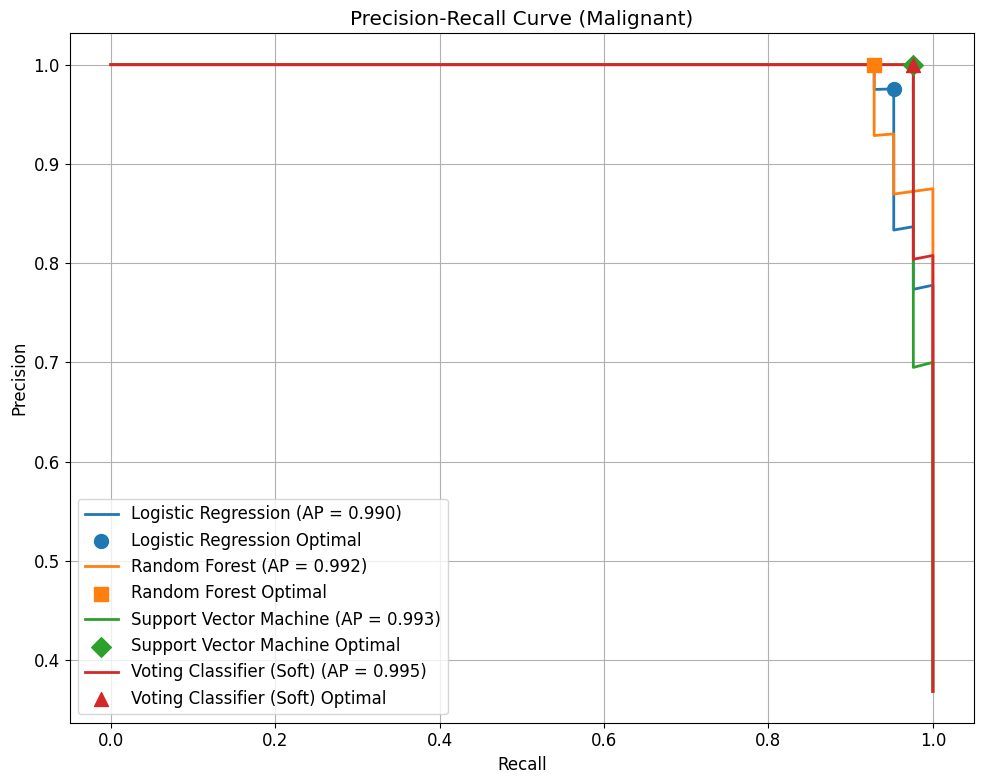

In [ ]:
models = {
    "Logistic Regression": best_lr_model,
    "Random Forest": best_rf_model,
    "Support Vector Machine": best_svm_model,
    "Voting Classifier (Soft)": best_voting_clf_model
}

plot_precision_recall_multiple(models, X_test, y_test)

### Advantages and Disadvantages of Voting Classifiers

Using a (soft) Voting Classifier over relying on a single base model offers several advantages:
- Improved Performance: The combined probability outputs of multiple models often allows the Voting Classifier to achieve a better generalization and performance compared to that of individual models (seen in the accuracy and F1-scores).
- Robustness: Able to mitigate the risk of overfitting or underfitting since base models can compensate for one another if one performs poorly on certain instances.
- Balanced Decision-Making: Soft voting uses averaged probabilities, which often leads to more stable and confident predictions (useful in imbalanced datasets).
- Error Reduction: Aggregation of diverse classifiers reduces variance and minimises the impact of errors from individual models.

There are also some disadvantages that must be considered when deciding between a (soft) Voting Classifier or simply using one of the base models:
- Reduced Interpretability: Ensemble methods are less interpretable, understanding reasoning behind a decision becomes more difficult.
- Increased Complexity:  Computational and implementation complexity increases with each model, each needing managing and tuning.
- Dependency on Base Model Quality: Performance of the ensemble is dependent on the quality of its base models. Poor base learners can degrade performance, especially if not properly calibrated.

Overall, the Voting Classifier provided the most accurate and reliable results, validating its utility in sensitive classification tasks like cancer diagnosis. While it introduces additional complexity, the trade-off is worthwhile in contexts where prediction accuracy is critical. However, in scenarios which require explainable outputs or resource efficient models, simpler models like Logistic Regression may still be appropriate.

# Random Forest
<a id=random_forest></a>

In this section we build a Random Forest classifier using the *Labeled Faces in the Wild dataset* (LFW) [2].



## 2.1 Labeled Faces in the Wild Dataset
<a id=load_LFW></a>



**Number of Examples and Their Representation:**
The subset of the Labeled Faces in the Wild (LFW) dataset used in this analysis contains 1,288 examples. Each example is a grayscale image of a single face, resized to $62 × 47$ pixels and flattened into a one-dimensional array. The images are pre-processed to center the facial region and are suitable for face recognition and verification tasks.

**Features of the Dataset:**
Each image is represented by 2,914 real-valued features, each corresponding to a pixel intensity value in the resized grayscale image. These features are of type `float32` and range from 0 to 255. These serve as the input to our Random Forest models used for face classification.

**Target Variable and Number of Classes:**
The target variable, categorical, represents the identity of the individual in each image. Our subset only includes images of people with at least 70 distinct images, resulting in 7 unique classes. Each class corresponds to a well-known public figure (Ariel Sharon, Colin Powell, Donald Rumsfeld, George W Bush, Gerhard Schroeder, Hugo Chavez, Tony Blair). Due to the relatively small number of minimum images per person required, class distribution is quite imbalanced with some individuals having significantly more samples than others.
This high degree of sparsity and class imbalance, has the potential to affect the performance of our Random Forest classification algorithm if applied to some randomly split subset of our dataset. Therefore, we should note that stratified sampling should be used when splitting the dataset to ensure that each class is proportionally represented in both the training and the testing sets.

These observations align with the documentation (`lfw_people['DESCR']`) and structure of the dataset.

In [ ]:
# Load dataset in directly from scikit-learn using code provided
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.5)

n_samples, h, w = lfw_people.images.shape

X = lfw_people.data
n_features = X.shape[1]

y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

In [ ]:
# Print dataset statistics
print("LFW Dataset Summary (subset with min_faces_per_person=70):")
print(f"Number of examples: {n_samples}")
print(f"Image dimensions: {h} x {w} pixels")
print(f"Number of features per example: {n_features}")
print(f"Number of unique individuals (classes): {n_classes}\n")

# Compute and display class distribution
class_counts = np.bincount(y)

class_distribution = pd.DataFrame({
    'Person': target_names,
    'Image Count': class_counts
}).sort_values(by='Image Count', ascending=False)

print("Class distribution (person vs. image count):")
print(f"{class_distribution.to_string()}")


# Display overall class distribution
y_series = pd.Series(y)

print("\nNormalised class distribution:")
print(y_series.value_counts(normalize=True).sort_index())

LFW Dataset Summary (subset with min_faces_per_person=70):
Number of examples: 1288
Image dimensions: 62 x 47 pixels
Number of features per example: 2914
Number of unique individuals (classes): 7

Class distribution (person vs. image count):
              Person  Image Count
3      George W Bush          530
1       Colin Powell          236
6         Tony Blair          144
2    Donald Rumsfeld          121
4  Gerhard Schroeder          109
0       Ariel Sharon           77
5        Hugo Chavez           71

Normalised class distribution:
0    0.059783
1    0.183230
2    0.093944
3    0.411491
4    0.084627
5    0.055124
6    0.111801
Name: proportion, dtype: float64


## 2.2 Split Data
<a id=split_data></a>


Splitting the dataset into training and testing subsets, with 80% of the data used for testing and 20% used for testing. The split is also stratified to ensure that the class distribution is preserved across subsets.

Stratification is required as the data does not equally represent the seven classes (unique individuals); Ariel Sharon (0), Colin Powell (1), Donald Rumsfeld (2), George W Bush (3), Gerhard Schroeder (4), Hugo Chavez (5), Tony Blair (6). This class imbalance was noted in section [2.1 Labeled Faces in the Wild Dataset](#load_lfw), with the class distribution observed printed in the *Normalised class distribution* table.

Stratification ensures we obtain training and test sets which preserve the class distribution as seen in the whole dataset. Avoids the risk of getting an unbalanced training set, poor generalisation in the model, and unreliable evaluation metrics.

The class distributions for both the training and testing sets closely match the original distribution within the dataset.

In [ ]:
# Split data into training and testing with 80:20 ratio
X_lfw_train, X_lfw_test, y_lfw_train, y_lfw_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check stratification maintained class distribution
y_train_series = pd.Series(y_lfw_train)
y_test_series = pd.Series(y_lfw_test)

print("\nTrain set class distribution:")
print(y_train_series.value_counts(normalize=True).sort_index())

print("\nTest set class distribution:")
print(y_test_series.value_counts(normalize=True).sort_index())


Train set class distribution:
0    0.059223
1    0.183495
2    0.094175
3    0.411650
4    0.084466
5    0.055340
6    0.111650
Name: proportion, dtype: float64

Test set class distribution:
0    0.062016
1    0.182171
2    0.093023
3    0.410853
4    0.085271
5    0.054264
6    0.112403
Name: proportion, dtype: float64


## 2.3 Classes
<a id=classes></a>


Displaying a random example for each class from the training set and display the image, each labelled with the name of the class. This is done to visualise the data we will be training the model on.

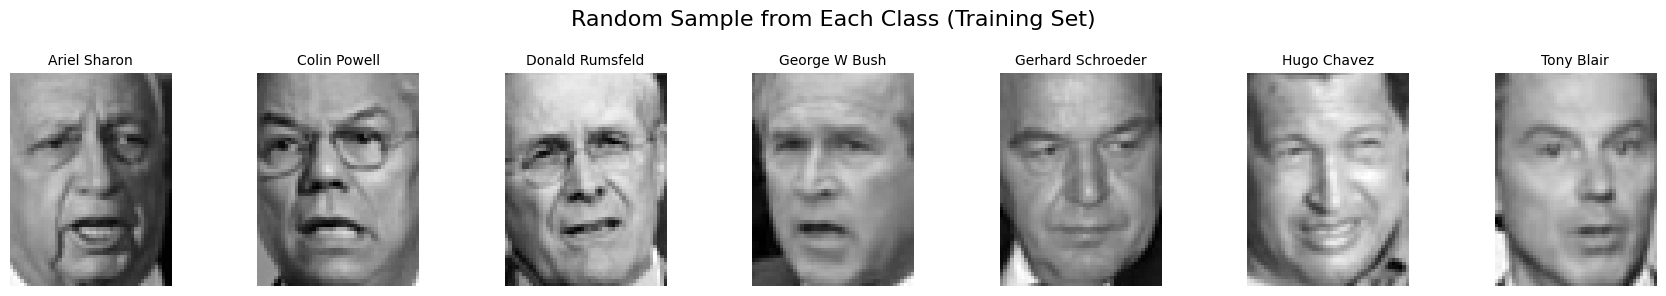

In [ ]:
# Extract images
images = lfw_people.images

# Create a dictionary to store one random example per class
unique_classes = np.unique(y)
sampled_indices = []

for cls in unique_classes:
    cls_indices = np.where(y == cls)[0]
    sampled_idx = np.random.choice(cls_indices)
    sampled_indices.append(sampled_idx)

# Plot the sampled images
n_classes = len(unique_classes)
fig, axes = plt.subplots(1, n_classes, figsize=(2.5 * n_classes, 3))
fig.suptitle("Random Sample from Each Class (Training Set)", fontsize=16)

for ax, idx in zip(axes, sampled_indices):
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(target_names[y[idx]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2.4 Random Forest Classifier
<a id=rf_classifier></a>


The classifier was trained using 1000 trees as specified, without hyperparameter tuning. Setting `max_features='sqrt'` to balance tree diversity and performance. Also setting `max_depth=None`, both of these settings were varied slightly and the most computationally efficient and accurate model output producing settings were chosen. The efficiency setting `n_jobs=-1` speeds up the computation by paralellising the forest training.

The trained Random Forest model is evaluated on the testing set, allowing us to see if our model generalises well on data it was not trained on. The precision, recall and f1-score of the model is displayed allowing us to empirically observe the performance of our model on the test set. The confusion matrix plot provide a visualisation of the accuracy in the predictions of the models and display exactly how many of the test examples fall within each category, helping to visually identify which classes are confused with one another.

### Results
George W Bush has almost perfect recall (0.98) but only moderate precision (0.58) scores. This is likely due to the difference in class distribution, he dominates the dataset with the most images by far. There is a high chance that the classifier is biased toward predicting this class.

Colin Powell has strong performance overall with high precision (0.822) and recall (0.787) scores. This is a balanced classification, indicating this class has good generalization.

Donald Rumsfeld, Gerhard Schroeder, Tony Blair displayed moderate precision and low recall scores. This suggests the model was occasionally able to correctly identify these individuals, but often under-predicts them. The under-prediction could be caused by the insufficient training samples or because of feature overlap with more dominant classes.

Hugo Chavez and Ariel Sharon received perfect precision but extremely low recall (especially Ariel Sharon at 0.062) scores. The classifier seems to only label samples from these classes when it is very confident, leading it to fail to detect most actual instances (an overly-cautious classifier). The high ratio of false negatives is likely caused by the class imbalance or a lack of distinct features within the classes.

The Random Forest classifier trained on the LFW pixel data has a moderate overall performance, displaying a strong precision but poor recall for minority classes. The classifier is ideal for detecting majority-class individuals, however the overly-cautious classification results in high quantity of false negatives for other classes. Recall (and fairness) could be improved by refining class balancing and feature representation within the training dataset used.


Classification Report (Random Forest on LFW data):
                   precision    recall  f1-score   support

     Ariel Sharon      1.000     0.062     0.118        16
     Colin Powell      0.822     0.787     0.804        47
  Donald Rumsfeld      1.000     0.333     0.500        24
    George W Bush      0.581     0.981     0.730       106
Gerhard Schroeder      0.857     0.273     0.414        22
      Hugo Chavez      1.000     0.214     0.353        14
       Tony Blair      0.667     0.345     0.455        29

         accuracy                          0.655       258
        macro avg      0.847     0.428     0.482       258
     weighted avg      0.746     0.655     0.606       258



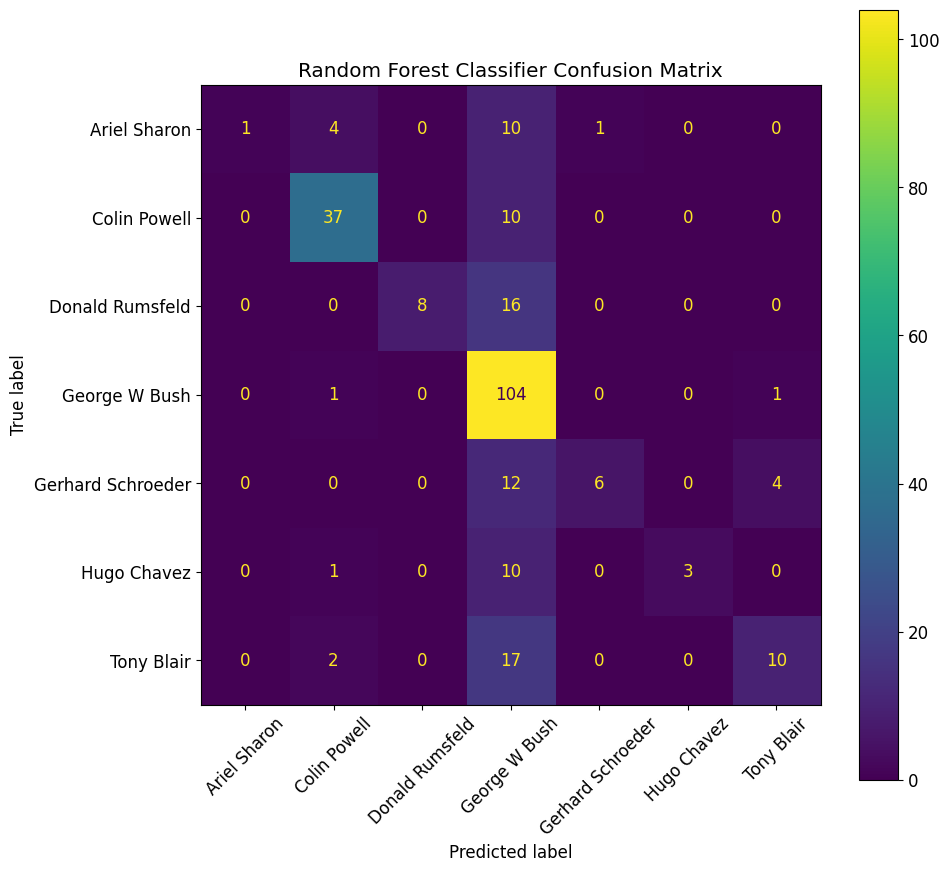

In [ ]:
# Train Random Forest classifier
rf = RandomForestClassifier(n_estimators=1000,    # 1000 tree forest
                            max_depth=None,        # Tree depth
                            max_features="sqrt",  # Features considered at split
                            random_state=42,
                            n_jobs=-1             # Speed up training
                            )
start = time.time()                               # Measure fitting time for comparison in section 2.7
rf.fit(X_lfw_train, y_lfw_train)
time_original = time.time() - start

# Predict on test set
y_lfw_pred = rf.predict(X_lfw_test)

# Classification table: precision, recall, F1-score
report_original = classification_report(y_lfw_test, y_lfw_pred, target_names=target_names, digits=3, output_dict=True)
print("Classification Report (Random Forest on LFW data):")
print(classification_report(y_lfw_test, y_lfw_pred, target_names=target_names, digits=3))


# Confusion Matrix
cm_original = confusion_matrix(y_lfw_test, y_lfw_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_original, display_labels=target_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Random Forest Classifier Confusion Matrix")
plt.show()

### Feature Importance

Due to the large quantity of features (2914 features), no single feature can be given much importance. Each fearture represents a pixel in the image. The pixel with the highest importance is still less than 0.0035. There is also a steep drop off in importance from the most important pixel to the 100th most importatn pixel, pixels further along the importance line are of relatively similar importance. Some of the less important features could potentially be ignored to produce a more accurate model.

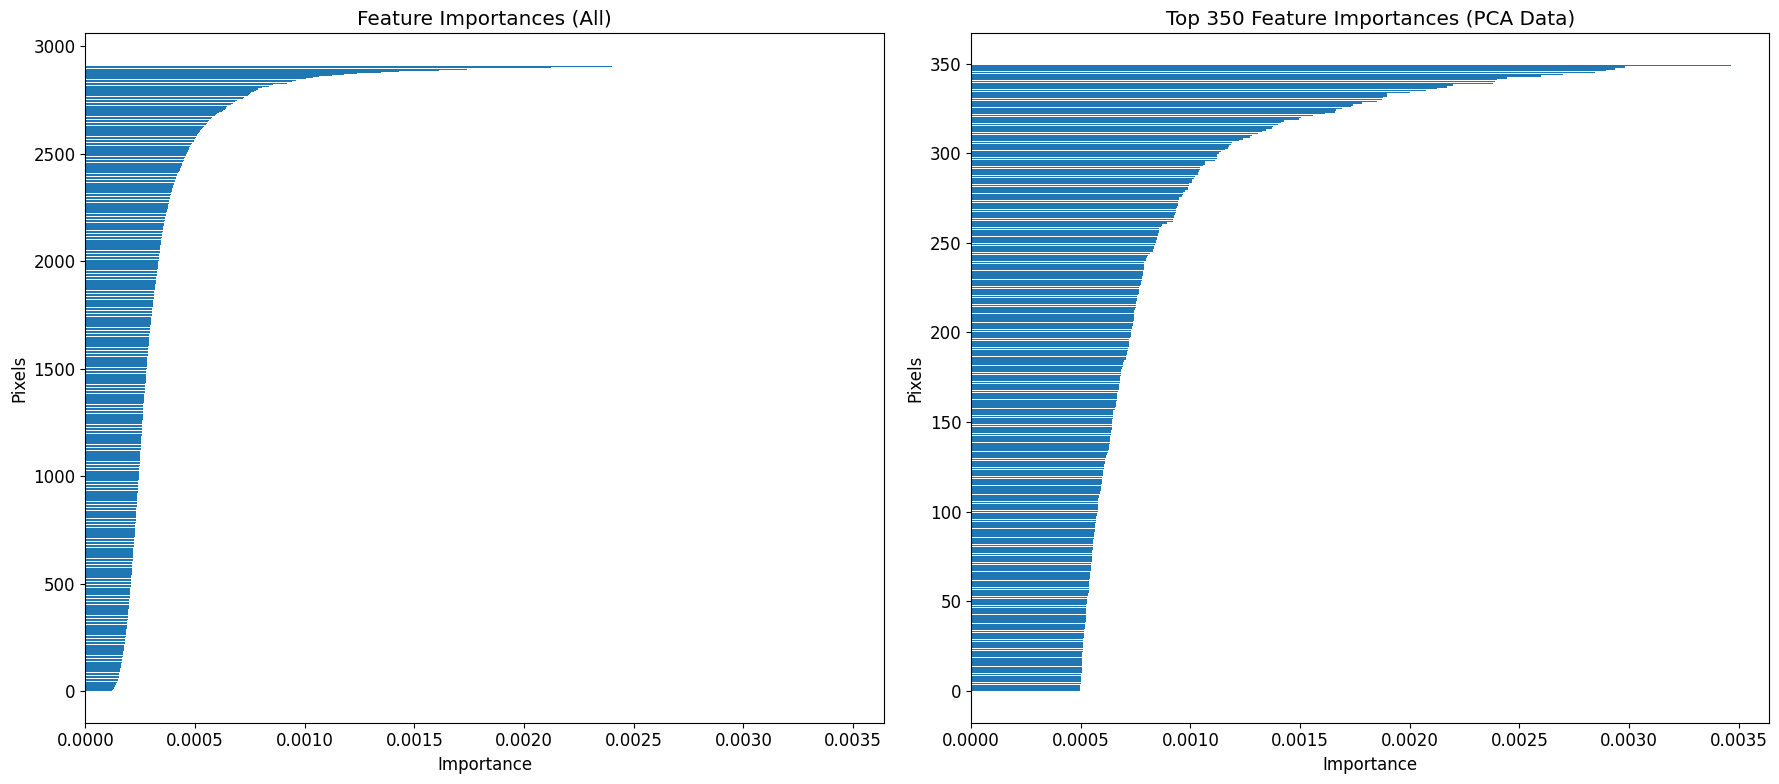

In [ ]:
# Feature Importances of Random Forest Classifier with zoom-in (top 350)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # 1 row, 2 columns

importances = rf.feature_importances_
indices = np.argsort(importances)      # Pixels ordered by importance

# All features importances
axes[0].barh(range(len(indices)), importances[indices], align='center')
axes[0].set_title("Feature Importances (All)")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Pixels")

# Top 350 feature importances
indices_350 = np.argsort(importances)[-350:]
axes[1].barh(range(len(indices_350)), importances[indices_350], align='center')
axes[1].set_title("Top 350 Feature Importances (PCA Data)")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

## 2.5 - Principla Component Analysis
<a id=pca></a>


We perform Principal Component Analysis (PCA) on the training data using scikit-learn, keeping 150 principal components.

Before PCS the data has 2914 dimensions and after PCA it has only 150 dimensions (principal components).

The explained variance ratio of the 150 principal components is 93.83%.

In [ ]:
# Perform PCA with 150 components on the training data
pca = PCA(n_components=150, whiten=True, random_state=42)
X_lfw_train_pca = pca.fit_transform(X_lfw_train)
X_lfw_test_pca = pca.transform(X_lfw_test)

# Dimensions before and after PCA
print(f"Original number of features: {X_lfw_train.shape[1]}")
print(f"Reduced number of features: {X_lfw_train_pca.shape[1]}")

# Explained variance ratio of the 150 principal components
explained_var = pca.explained_variance_ratio_.sum()
print(f"Total variance explained by 150 components: {explained_var:.2%}")

Original number of features: 2914
Reduced number of features: 150


### Eigenfaces

Eigenfaces are the principal axes in the feature space of the PCA transformed data and are often used face recognition tasks. The first 10 eigenfaces are displayed below.

The eigenfaces are essentially "templates" of variation in face appearance, similar to a blurry face which represents a common pattern. They represent the directions in the data along which the faces vary the most, hence principal axes.

The original face images can be represented as a weighted sum of these eigenfaces, similar concept as basis vectors within a vector space.
As seen in the those displayed, the first few eigenfaces capture major features (e.g. regions of extreme light/dark, general facial structure) and the eigenfaces further along capture finer details or, potentially, noise.

Projecting a face onto these eigenfaces allows us to compress the representation of the face without losing a significant amount of identity information, ideal for tasks like recognition.

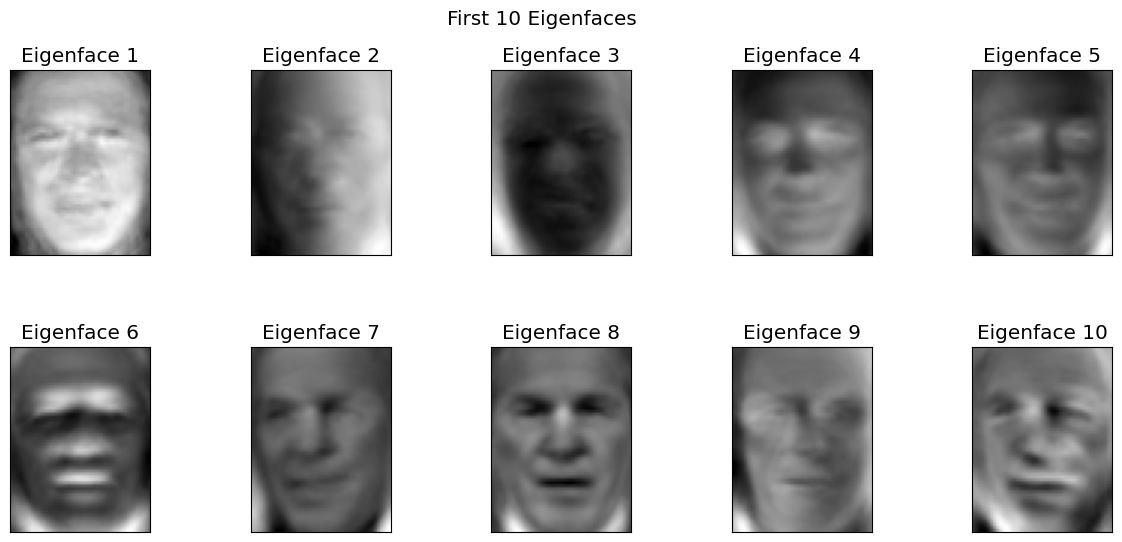

In [ ]:
# The first 10 eigenfaces
eigenfaces = pca.components_.reshape((150, h, w))

fig, axes = plt.subplots(2, 5, figsize=(15, 6),
                         subplot_kw={'xticks': [], 'yticks': []},
                         gridspec_kw=dict(hspace=0.5, wspace=0.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f"Eigenface {i + 1}")
plt.suptitle("First 10 Eigenfaces")
plt.show()

## 2.6 Training on PCA Transformed Data
<a id=train_pca></a>


The classifier was again trained using 1000 trees as specified, without hyperparameter tuning. Setting `max_features='sqrt'` to balance tree diversity and performance. Also setting `max_depth=None`, both of these settings were varied slightly and the most computationally efficient and accurate model output producing settings were chosen. When `max_features=None` a slightly better accuracy was achieved, however the model training time increased significanly and so it was not retained. The efficiency setting `n_jobs=-1` speeds up the computation by paralellising the forest training. However, this time the classifier was trained using the PCA training data created in the previous section.

The PCA data trained Random Forest model is evaluated on the testing set, allowing us to see if our model generalises well on data it was not trained on. The precision, recall and f1-score of the model is displayed allowing us to empirically observe the performance of our model on the test set. The confusion matrix plot provide a visualisation of the accuracy in the predictions of the models and display exactly how many of the test examples fall within each category, helping to visually identify which classes are confused with one another

### Results
George W Bush has perfect recall but only moderate precision (0.47), indicating over-prediction of this class. This is again likely due to the difference in class distribution, dominating the dataset with the most images by far. There is a high chance that the classifier is again biased toward predicting this class.

Classes like Ariel Sharon, Hugo Chavez, Gerhard Schroeder have zero for precision, recall, and F1-score, no samples were correctly predicted by our model for their classes. It is likely that the PCA-transformation has either obscured or discarded some key features required to distinguish these specific classes (identities).

Colin Powell has a very high precision (0.96), indicating high confidence in predictions, but recall (0.55) is significantly lower when compared to the model trained on original data. Suggesting the PCA transformation again removed informative features useful for identifying this class.

Donald Rumsfeld and Tony Blair precision is moderate to high, however, recall is very low. The classifier is only able to recognise a few true samples, this indicates the model struggles to generalize on the transformed samples.

The Random Forest model trained on the PCA-transformed training data shows that even if dimensionality reduction is able to simplify the learning task, excessive feature loss severely hinders classification and this is especially the case for underrepresented classes. The model failed to generalize beyond the majority classes, with only 53.5% accuracy and complete failure on multiple identities. The ability to retaining class-distinctive detailsfor multiple classes is fundamental for face recognition, and so PCA might require reconfiguration or replacement with a more sophisticated approach.

Classification Report (Random Forest on PCA-transformed data):
                   precision    recall  f1-score   support

     Ariel Sharon      0.000     0.000     0.000        16
     Colin Powell      0.963     0.553     0.703        47
  Donald Rumsfeld      0.750     0.125     0.214        24
    George W Bush      0.473     1.000     0.642       106
Gerhard Schroeder      0.000     0.000     0.000        22
      Hugo Chavez      0.000     0.000     0.000        14
       Tony Blair      1.000     0.103     0.188        29

         accuracy                          0.535       258
        macro avg      0.455     0.255     0.250       258
     weighted avg      0.552     0.535     0.433       258



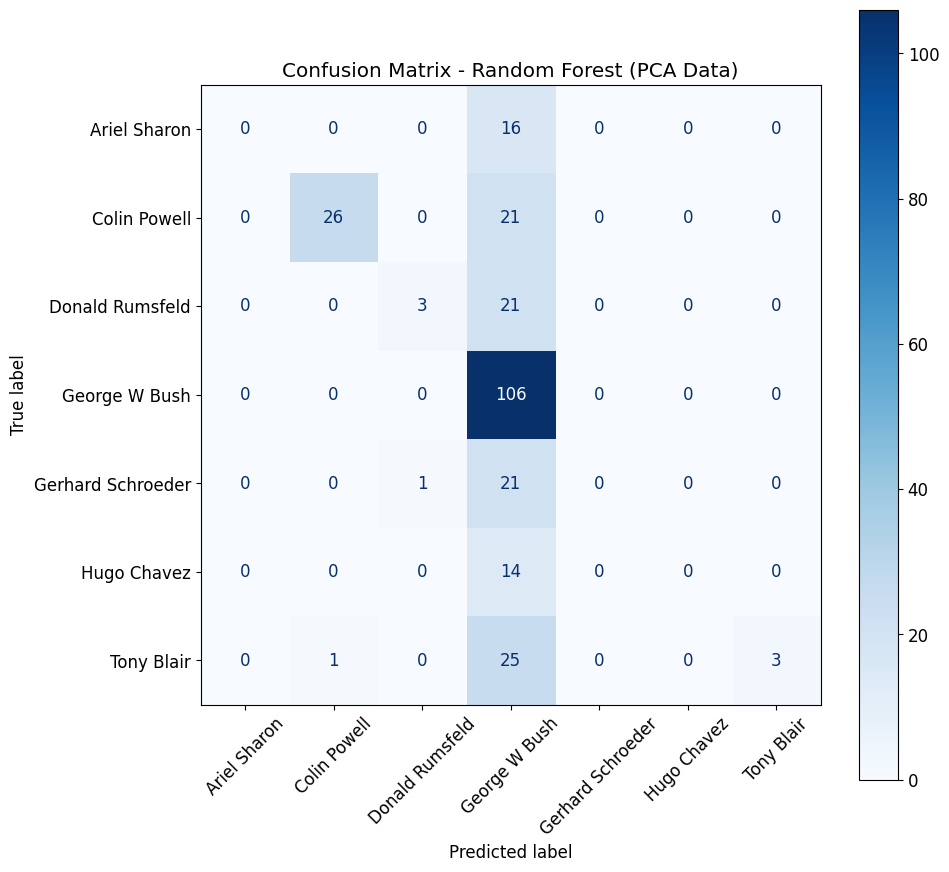

In [ ]:
# Train a Random Forest classifier on PCA-transformed data
rf_pca = RandomForestClassifier(n_estimators=1000,    # 1000 trees in forest
                                max_depth=None,        # Tree depth
                                max_features="sqrt",  # Features considered at split
                                random_state=42,
                                n_jobs=-1             # Speed up training
                                )
start = time.time()                                 # Measure fitting time for comparison in section 2.7
rf_pca.fit(X_lfw_train_pca, y_lfw_train)
time_pca = time.time() - start

# Predict on the PCA-transformed test data
y_lfw_pred_pca = rf_pca.predict(X_lfw_test_pca)

# Classification table: precision, recall, F1-score
report_pca = classification_report(y_lfw_test, y_lfw_pred_pca, target_names=target_names, zero_division=0, digits=3, output_dict=True)
print("Classification Report (Random Forest on PCA-transformed data):")
print(classification_report(y_lfw_test, y_lfw_pred_pca, target_names=target_names, zero_division=0, digits=3))

# Plot confusion matrix
cm_pca = confusion_matrix(y_lfw_test, y_lfw_pred_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=target_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest (PCA Data)")
plt.show()

-> The following is not used in the comparison section as it was only ran to see if a better could be produced with this setting

Classification Report (Random Forest on PCA-transformed data):
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       1.00      0.15      0.26        47
  Donald Rumsfeld       1.00      0.17      0.29        24
    George W Bush       0.43      1.00      0.60       106
Gerhard Schroeder       0.00      0.00      0.00        22
      Hugo Chavez       0.00      0.00      0.00        14
       Tony Blair       0.00      0.00      0.00        29

         accuracy                           0.45       258
        macro avg       0.35      0.19      0.16       258
     weighted avg       0.45      0.45      0.32       258



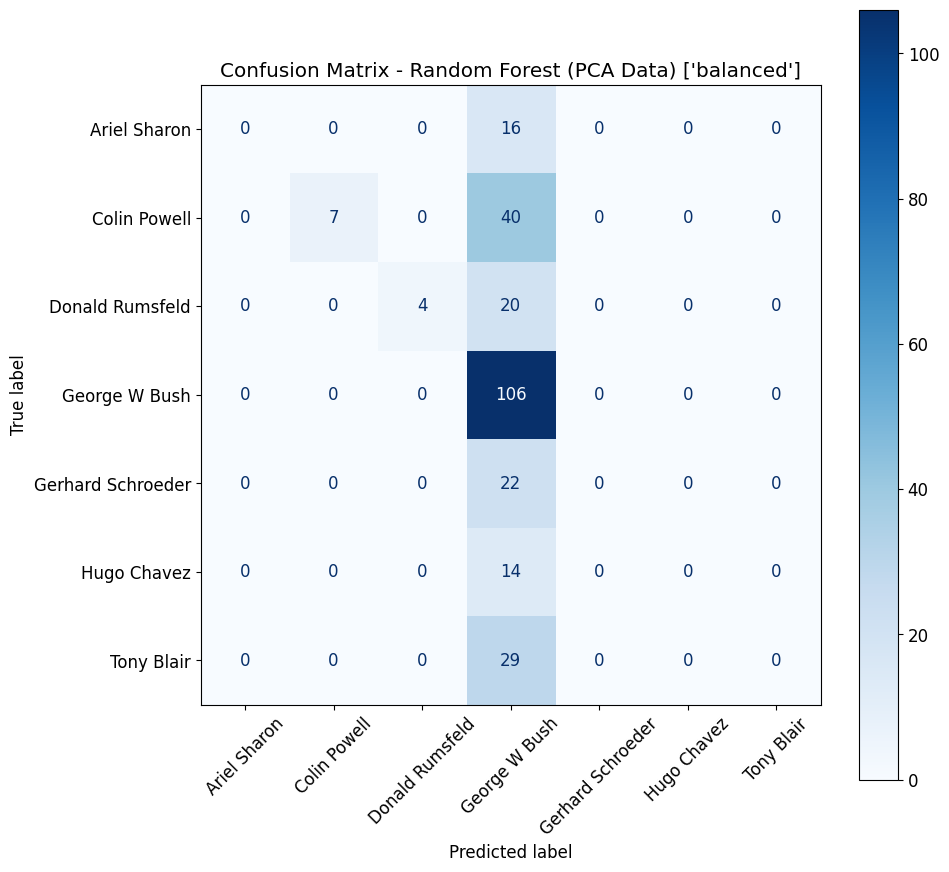

In [ ]:
## Exploring different setting - ignore

# Train a Random Forest classifier with class_weight='balanced' on PCA-transformed data
rf_pca_balanced = RandomForestClassifier(n_estimators=1000,
                                         max_depth=None,
                                         max_features="sqrt",
                                         random_state=42,
                                         n_jobs=-1,
                                         class_weight='balanced'  # Class balancing technique
                                         )
rf_pca_balanced.fit(X_lfw_train_pca, y_lfw_train)

# Predict on the PCA-transformed test data
y_lfw_pred_pca_balanced = rf_pca_balanced.predict(X_lfw_test_pca)

# Classification report: precision, recall, F1-score
print("Classification Report (Random Forest on PCA-transformed data):")
print(classification_report(y_lfw_test, y_lfw_pred_pca_balanced, target_names=target_names, zero_division=0))


# Plot confusion matrix
cm_pca_b = confusion_matrix(y_lfw_test, y_lfw_pred_pca_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca_b, display_labels=target_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest (PCA Data) ['balanced']")
plt.show()

## 2.7 Comparison
<a id=comparison></a>



### Performance


The Random Forest trained on the original data vastly outperforms the PCA-transformed model across all key metrics:
- Higher overall accuracy (higher by 12%)
- Better balance across classes, implied by stronger macro and weighted F1-scores
- Consistently able to detect of classes (whereas, the PCA model failed to identify three classes entirely)

When considering both generalization and fairness, the original model demonstrated a greater robustness and reliability.

This result is to be expectated. PCA is unsupervised in its transformation, reducing dimensionality without regard for class labels. Therefore features critical for distinguishing specific individuals (especially minority classes) have the potential to be lost. Overly aggressive PCA can suppress this granularity, obfuscating subtle visual distinctions which may be essential for distinction.

Random Forest models, while robust, are not particularly well-suited for heavily reduced (small) feature spaces. A deficit of features leads to their decision trees lacking meaningful splits. Contrastingly, the original data with all features preserved, enabled the Random Forest to leverage the discriminative details effectively.

Accuracy (Original): 0.655
Accuracy (PCA): 0.535



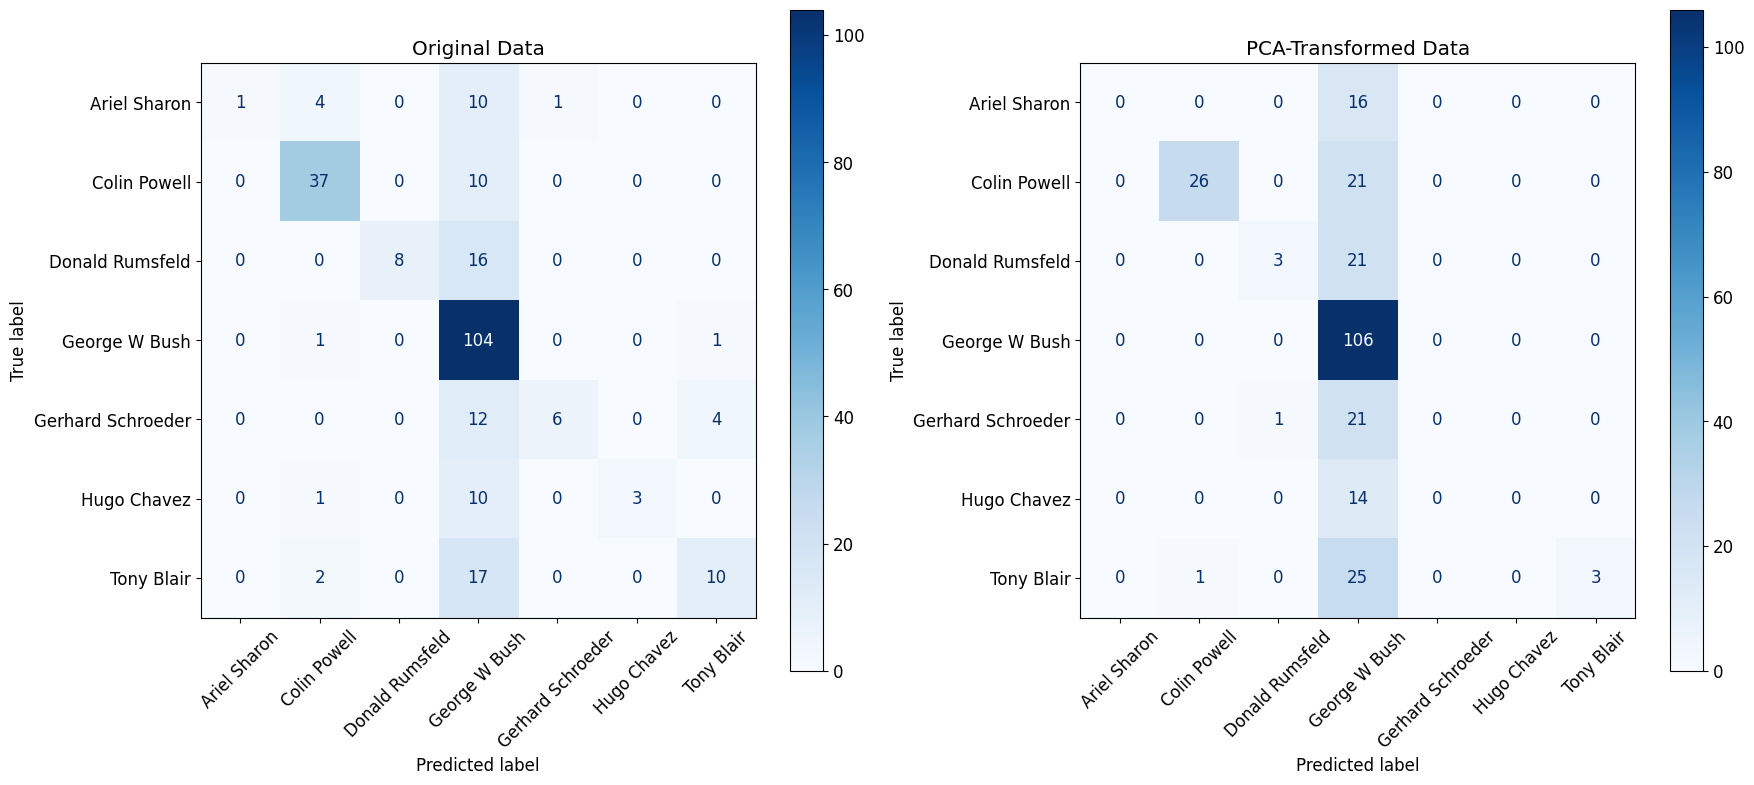

In [ ]:
# Accuracy
print(f"Accuracy (Original): {report_original['accuracy']:.3f}")
print(f"Accuracy (PCA): {report_pca['accuracy']:.3f}\n")

# Confusion Matrices Side by Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_original, display_labels=target_names)
disp1.plot(ax=axes[0], xticks_rotation=45, cmap='Blues')  # Blues used for clarity
axes[0].set_title("Original Data")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=target_names)
disp2.plot(ax=axes[1], xticks_rotation=45, cmap='Blues')  # Blues used for clarity
axes[1].set_title("PCA-Transformed Data")

plt.tight_layout()
plt.show()

### Time Taken to Train

The Random Forest model trained on the PCA transformed data (11.2 seconds) was much faster than the model trained on the original data (38.7 seconds), which is more than 3x slower.

This significant difference in training time is to be expected and can be attributed to the dimensionality reduction performed by PCA. Originally, the dataset contained 2,914 features per image. The PCA transformation, reduced this number to only 150 principal components. There were fewer features for the Random Forest algorithm to consider at each split, shallower decision trees (fewer features typically result in simpler splits), and less overall computational complexity.

PCA significantly accelerates training by reducing the number of features while, hopefully, retaining most of the variance in the data. The dimensionality and information retention trade-off is especially beneficial in high-dimensional datasets such as facial image data. Time savings are even more pronounced with bigger datasets or models of higher complexity. Therefore, when considering performance and efficiency, PCA is valuable as a preprocessing step when working with computationally intensive algorithms such as Random Forests on image data.




In [ ]:
# Time taken to train each model
print(f"\nTraining Time (Original): {time_original:.2f} seconds")
print(f"Training Time (PCA): {time_pca:.2f} seconds")


Training Time (Original): 38.73 seconds
Training Time (PCA): 11.21 seconds


### Feature Importance

The shape of the feature importance plots for both models have similar shapes, steep drop-offs in importance following after the most influential features. This disparity indicates that a relatively small subset of features contribute the most to classification performance.

Between the two graphs, however, there is a vast differnce in the importance magnitude and feature density. In the original data model, the importance values are generally sparce and low with no individual pixel (feature) providing a significant contribution.
In comparison, the PCA-transformed data model many components exhibited a higher relative importance, with even the least significant component having a higher importance than the most important pixel in the original data model.

These observations are to be expected, we can attribute them to the nature of PCA transormations. PCA combine correlated pixel features into principal components which capture maximum variance. The resulting PCA components all represent a meaningful combination of pixel patterns, rather than individual raw pixel intensity values. Better aligned with class-discriminating structures, these components are naturally more informative to the Random Forest model.

In contrast, the original pixel features are noisy and highly redundant (i.e. adjacent pixels carry similar values). Therefore, any single pixel can only carry a miniscule fraction of the total discriminative power.

Aligning with expectations, the PCA-transformed model displays stronger and more concentrated feature importance. Reinforcing the use of PCA for improving the clarity of which features (components) induce model performance.
This comparison confirms that feature transformation techniques such as PCA have the potential to produce more interpretable and effective models within high-dimensional spaces such as in facial image recognition.


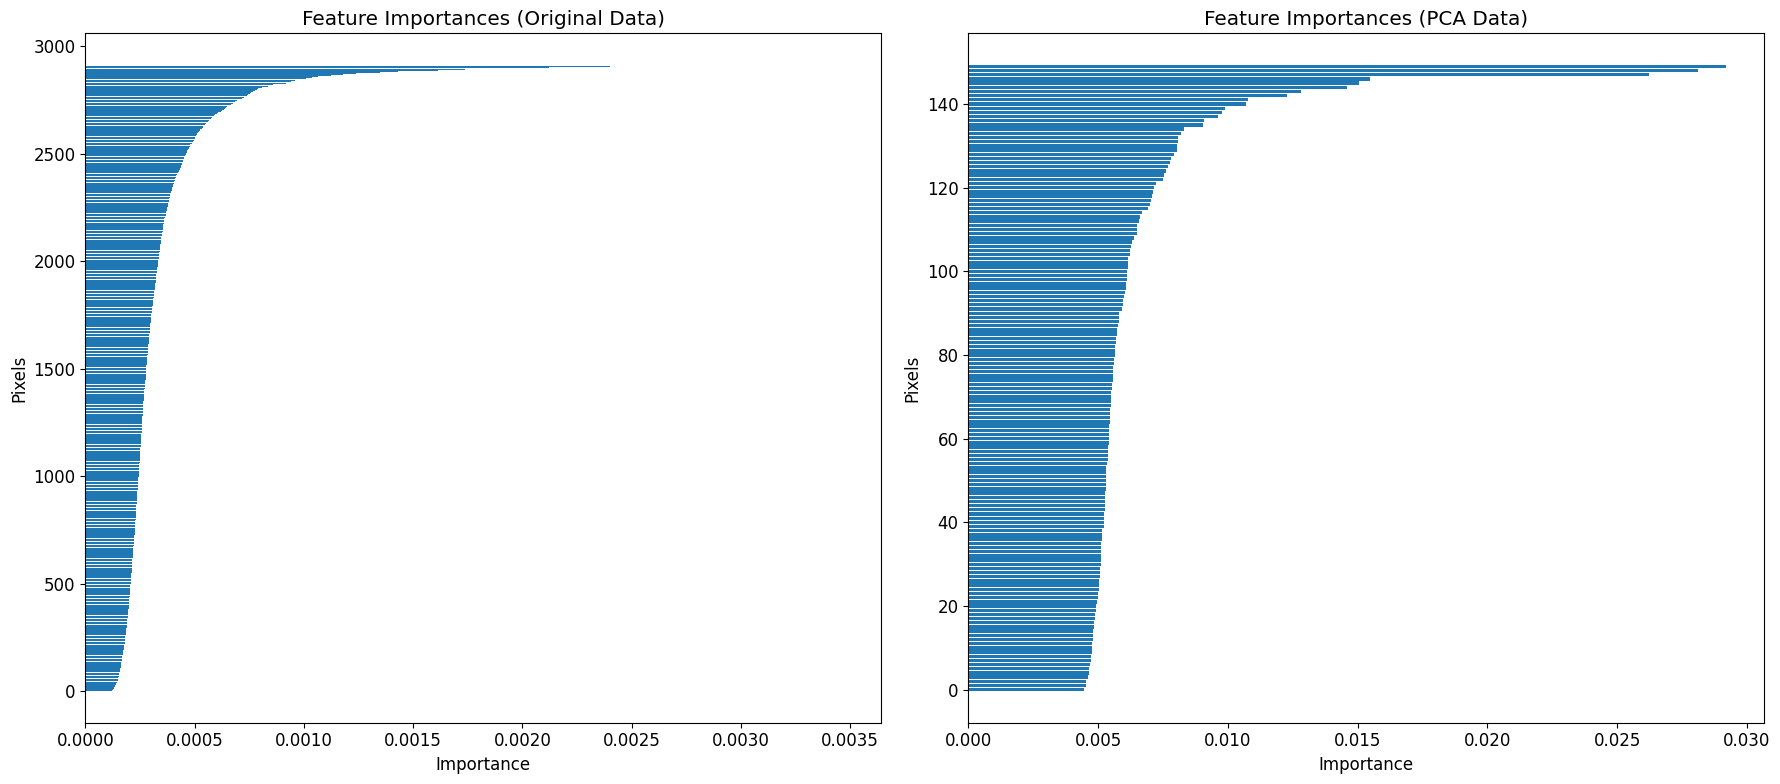

In [ ]:
# Feature Importances side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # 1 row, 2 columns

# Original data importances (importances and indices from section 2.4)
axes[0].barh(range(len(indices)), importances[indices], align='center')
axes[0].set_title("Feature Importances (Original Data)")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Pixels")

# PCA-transformed data importances
importances_pca = rf_pca.feature_importances_
indices_pca = np.argsort(importances_pca)      # Pixels ordered by importance
axes[1].barh(range(len(indices_pca)), importances_pca[indices_pca], align='center')
axes[1].set_title("Feature Importances (PCA Data)")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

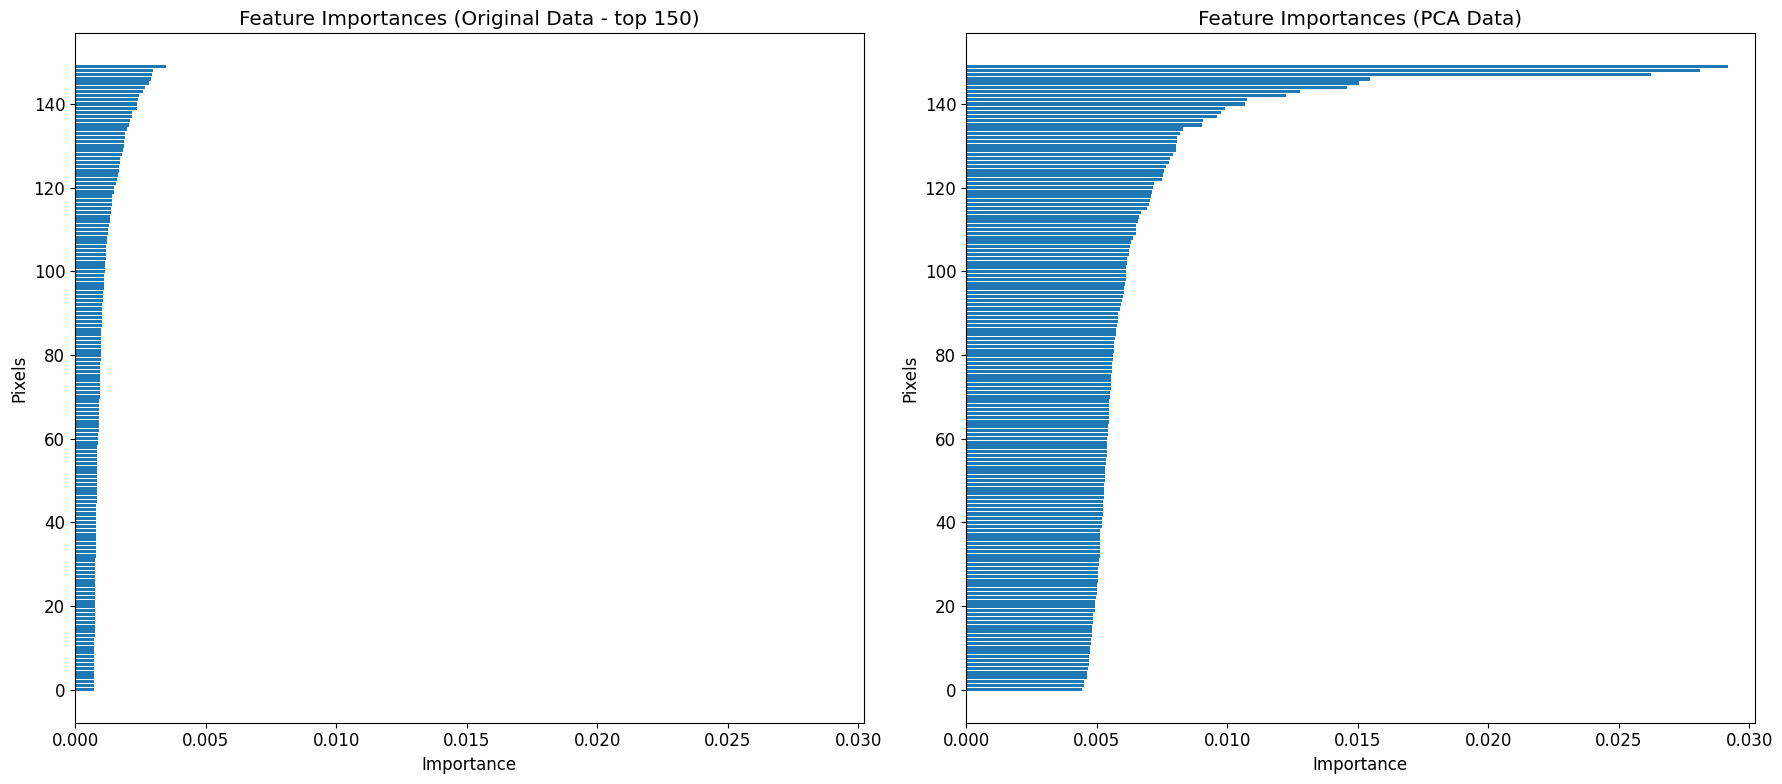

In [ ]:
# Feature Importances side-by-side with same axis scales
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # 1 row, 2 columns

# Original data top 150 importances for same y-axis scale (importances from section 2.4)
indices_150 = np.argsort(importances)[-150:]
axes[0].barh(range(len(indices_150)), importances[indices_150], align='center')
axes[0].set_title("Feature Importances (Original Data - top 150)")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Pixels")

# PCA-transformed data importances
importances_pca = rf_pca.feature_importances_
indices_pca = np.argsort(importances_pca)      # Pixels ordered by importance
axes[1].barh(range(len(indices_pca)), importances_pca[indices_pca], align='center')
axes[1].set_title("Feature Importances (PCA Data)")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Pixels")

# Set same x-axis scales
max_val = max(importances.max(), importances_pca.max())
x_max = np.ceil(max_val * 10000) / 10000 + 0.001
axes[0].set_xlim(0, x_max)
axes[1].set_xlim(0, x_max)

plt.tight_layout()
plt.show()

# References
<a id=references></a>
[1] [Street, W., W. Wolberg, and O. Mangasarian. ‘Breast Cancer Wisconsin (Diagnostic)’. UCI Machine Learning Repository, 1993.](https://doi.org/10.24432/C5DW2B)

[2] [Labeled Faces in the Wild Database Page](http://vis-www.cs.umass.edu/lfw/)